In [35]:
%pip install kagglehub pandas numpy matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
data = pd.read_csv("data/train.csv")

In [38]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
data = np.array(data)
m, n = data.shape

np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0].astype(int)
X_dev = data_dev[1:n]
X_dev = X_dev / 255.0

data_train = data[1000:m].T
Y_train = data_train[0].astype(int)
X_train = data_train[1:n]
X_train = X_train / 255.0

In [40]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5

    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5

    return W1, b1, W2, b2


def reLU(Z):
    return np.maximum(0, Z)


def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)
    exp_Z = np.exp(Z)
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)


def forward_prop(W1, b1, W2, b2, X):

    Z1 = W1.dot(X) + b1
    A1 = reLU(Z1)

    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2


def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))

    one_hot_Y[np.arange(Y.size), Y] = 1

    one_hot_Y = one_hot_Y.T

    return one_hot_Y


def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size

    one_hot_Y = one_hot(Y)

    dZ2 = A2 - one_hot_Y

    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = W2.T.dot(dZ2) * (Z1 > 0)

    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2


def update_params(
        W1, b1,
        W2, b2,
        dW1, db1,
        dW2, db2,
        alpha
):

    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1

    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2

    return W1, b1, W2, b2

In [41]:
def get_predictions(A2):
    return np.argmax(A2, axis=0)


def get_accuracy(predictions, Y):
    return np.mean(predictions == Y) * 100


def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()

    accuracy_history = []

    for i in range(iterations):

        Z1, A1, Z2, A2 = forward_prop(
            W1, b1, W2, b2, X
        )

        dW1, db1, dW2, db2 = back_prop(
            Z1, A1, Z2, A2, W2, X, Y
        )

        W1, b1, W2, b2 = update_params(
            W1, b1, W2, b2,
            dW1, db1, dW2, db2,
            alpha
        )

        predictions = get_predictions(A2)
        accuracy = get_accuracy(predictions, Y)

        accuracy_history.append(accuracy)

        if i % 10 == 0:
            predictions = get_predictions(A2)

            print("Iteration:", i)
            print("Accuracy:", accuracy, "%")
            print("Prediction counts:", np.unique(predictions, return_counts=True))

    return W1, b1, W2, b2, accuracy_history

In [44]:
W1, b1, W2, b2, accuracy_history = gradient_descent(X_train, Y_train, 0.1, 500)

Iteration: 0
Accuracy: 14.346341463414634 %
Prediction counts: (array([0, 1, 2, 3, 4, 5, 7, 8]), array([21735,   998,  4304,  4395,   239,  2264,  4911,  2154]))
Iteration: 10
Accuracy: 23.443902439024388 %
Prediction counts: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([6399, 3960, 4781, 7166, 2197, 2448,   19, 6299, 4914, 2817]))
Iteration: 20
Accuracy: 34.387804878048776 %
Prediction counts: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([5814, 5387, 5729, 6259, 2856, 1705,  862, 5358, 2264, 4766]))
Iteration: 30
Accuracy: 43.94146341463415 %
Prediction counts: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([5315, 6334, 5040, 5856, 3127, 1392, 3318, 5498,  728, 4392]))
Iteration: 40
Accuracy: 49.94634146341463 %
Prediction counts: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([5091, 6951, 3952, 5447, 3522, 1478, 4192, 5593,  873, 3901]))
Iteration: 50
Accuracy: 54.28048780487805 %
Prediction counts: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([4963, 6770, 3670, 5152, 3925, 1659, 42

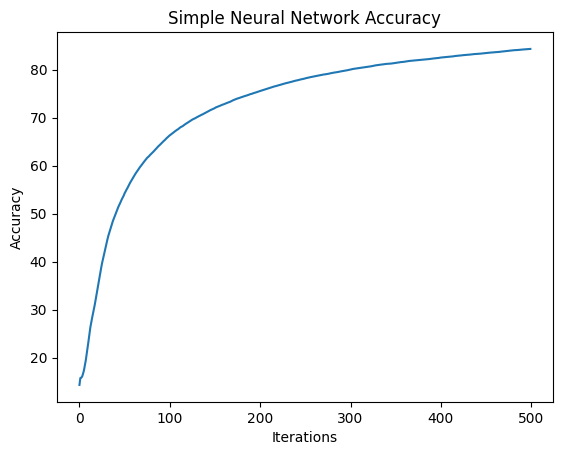

In [45]:
# Plot the accuracy history for graph
plt.plot(accuracy_history)

plt.xlabel ("Iterations")
plt.ylabel ("Accuracy")
plt.title ("Simple Neural Network Accuracy")

plt.show()

In [50]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)

    predictions = get_predictions(A2)

    return predictions

In [51]:
def show_prediction(index, X, Y, W1, b1, W2, b2):

    current_image = X[:, index, None]

    prediction = make_predictions(
        current_image,
        W1,
        b1,
        W2,
        b2
    )

    label = Y[index]

    print("Prediction:", prediction[0])
    print("Actual Label:", label)

    image = X[:, index].reshape(28, 28)

    plt.imshow(image, cmap="gray")
    plt.title(
        f"Prediction: {prediction[0]} | Actual: {label}"
    )

    plt.axis("off")
    plt.show()

Prediction: 8
Actual Label: 8


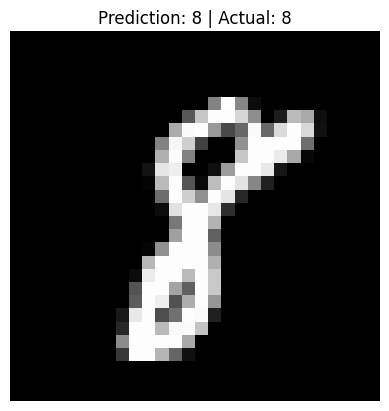

In [54]:
show_prediction(
    0,
    X_dev,
    Y_dev,
    W1,
    b1,
    W2,
    b2
)